## 1. Standardize domain names

English and German domain labels are spelled slightly differently in places (e.g. `Politics and Law` vs `Politics & Law`, `Science` vs `Natural Science`). This mapping makes sure both datasets use the **same full domain names**, so tables and plots are directly comparable.

In [15]:
DOMAIN_FULL_NAMES = {
    "Art": "Art",
    "Business": "Business",
    "Education": "Education",
    "Entertainment": "Entertainment",
    "History": "History",
    "Medicine": "Medicine",
    "Philosophy": "Philosophy",
    "Politics & Law": "Politics & Law",
    "Politics and Law": "Politics & Law",
    "Psychology": "Psychology",
    "Science": "Science",
    "Natural Science": "Science",
    "Technology": "Technology",
}

def standardize_domain(series):
    """Map domain labels to a single consistent full name."""
    mapped = series.map(DOMAIN_FULL_NAMES)
    return mapped.fillna(series)

## 2. Load German texts (directly from Excel file)

In [16]:
import pandas as pd

de_file = "German_original_TED_talks (4).xlsx"

de_df = pd.read_excel(
    de_file,
    sheet_name="Tabelle1"
)

de_texts = (
    de_df[["Text_ID", "Domain", "Gender"]]
    .dropna(subset=["Text_ID"])
    .drop_duplicates(subset=["Text_ID"])
    .rename(columns={"Text_ID": "file"})
    .copy()
)

de_texts["Domain"] = standardize_domain(de_texts["Domain"])

print("German unique texts:", len(de_texts))

German unique texts: 110


## 3. Load English texts (directly from the TED Talks Excel file)

In [17]:
en_file = "TED Data-All Talks (2).xlsx"

en_df = pd.read_excel(
    en_file,
    sheet_name="Full_table"
)

en_texts = (
    en_df[["ID", "Topic", "Gender"]]
    .dropna(subset=["ID"])
    .drop_duplicates(subset=["ID"])
    .rename(columns={"ID": "file", "Topic": "Domain"})
    .copy()
)

en_texts["Domain"] = standardize_domain(en_texts["Domain"])

print("English unique texts:", len(en_texts))

English unique texts: 190


## 4. Frequency and percentage tables

In [18]:
def domain_gender_frequency_table(texts_df):

    table = pd.crosstab(
        texts_df["Domain"],
        texts_df["Gender"]
    )

    table["Total"] = table.sum(axis=1)

    # Add total row
    table.loc["Total"] = table.sum(axis=0)

    return table


def domain_gender_percentage_table(texts_df):

    # Count gender within each domain
    counts = pd.crosstab(
        texts_df["Domain"],
        texts_df["Gender"]
    )

    # Convert each domain to percentages
    percentages = counts.div(
        counts.sum(axis=1),
        axis=0
    ) * 100

    return percentages.round(2)

In [19]:
# English
en_frequency = domain_gender_frequency_table(en_texts)
en_percentage = domain_gender_percentage_table(en_texts)

# German
de_frequency = domain_gender_frequency_table(de_texts)
de_percentage = domain_gender_percentage_table(de_texts)

In [20]:
print("========== ENGLISH: RAW FREQUENCIES ==========")
display(en_frequency)

print("\n========== ENGLISH: PERCENTAGES ==========")
display(en_percentage)

print("\n========== GERMAN: RAW FREQUENCIES ==========")
display(de_frequency)

print("\n========== GERMAN: PERCENTAGES ==========")
display(de_percentage)

========== ENGLISH: RAW FREQUENCIES ==========


Gender,F,M,Total
Domain,,,
Art,6,10,16
Business,6,10,16
Education,9,6,15
Entertainment,7,8,15
History,8,7,15
Medicine,7,10,17
Philosophy,2,13,15
Politics & Law,11,6,17
Psychology,12,5,17



========== ENGLISH: PERCENTAGES ==========


Gender,F,M
Domain,,
Art,37.50,62.50
Business,37.50,62.50
Education,60.00,40.00
Entertainment,46.67,53.33
History,53.33,46.67
Medicine,41.18,58.82
Philosophy,13.33,86.67
Politics & Law,64.71,35.29
Psychology,70.59,29.41



========== GERMAN: RAW FREQUENCIES ==========


Gender,F,M,Total
Domain,,,
Art,5,5,10
Business,5,5,10
Education,5,5,10
Entertainment,5,5,10
History,5,5,10
Medicine,5,5,10
Philosophy,5,5,10
Politics & Law,5,5,10
Psychology,5,5,10



========== GERMAN: PERCENTAGES ==========


Gender,F,M
Domain,,
Art,50.0,50.0
Business,50.0,50.0
Education,50.0,50.0
Entertainment,50.0,50.0
History,50.0,50.0
Medicine,50.0,50.0
Philosophy,50.0,50.0
Politics & Law,50.0,50.0
Psychology,50.0,50.0


## 5. Plots: gender distribution across domains

In [21]:
import matplotlib.pyplot as plt
import pandas as pd

def plot_gender_stacked(df, title):

    # Count unique texts per Domain x Gender
    counts = pd.crosstab(
        df["Domain"],
        df["Gender"]
    )

    # Create figure
    fig, ax = plt.subplots(figsize=(13, 7))

    # Stacked bar chart
    counts.plot(
        kind="bar",
        stacked=True,
        ax=ax
    )

    # Add individual counts inside each segment
    for bar_index, domain in enumerate(counts.index):

        cumulative = 0

        for gender in counts.columns:

            value = counts.loc[domain, gender]

            if value > 0:

                # Put count in middle of segment
                ax.text(
                    bar_index,
                    cumulative + value / 2,
                    str(value),
                    ha="center",
                    va="center",
                    color="white",
                    fontweight="bold",
                    fontsize=11
                )

                cumulative += value

        # Total above the bar
        total = counts.loc[domain].sum()

        ax.text(
            bar_index,
            total + 0.5,
            f"{total}",
            ha="center",
            va="bottom",
            fontweight="bold",
            color="gray",
            fontsize=11
        )

    # Labels
    ax.set_title(title, fontsize=15, fontweight="bold")
    ax.set_xlabel("Domain", fontsize=12)
    ax.set_ylabel("Number of texts", fontsize=12)

    # Rotate domain names
    plt.xticks(
        rotation=45,
        ha="right"
    )

    # Legend
    ax.legend(
        title="Gender",
        bbox_to_anchor=(1.02, 1),
        loc="upper left"
    )

    # Give some space above totals
    ax.set_ylim(
        0,
        counts.sum(axis=1).max() * 1.15
    )

    plt.tight_layout()
    plt.show()

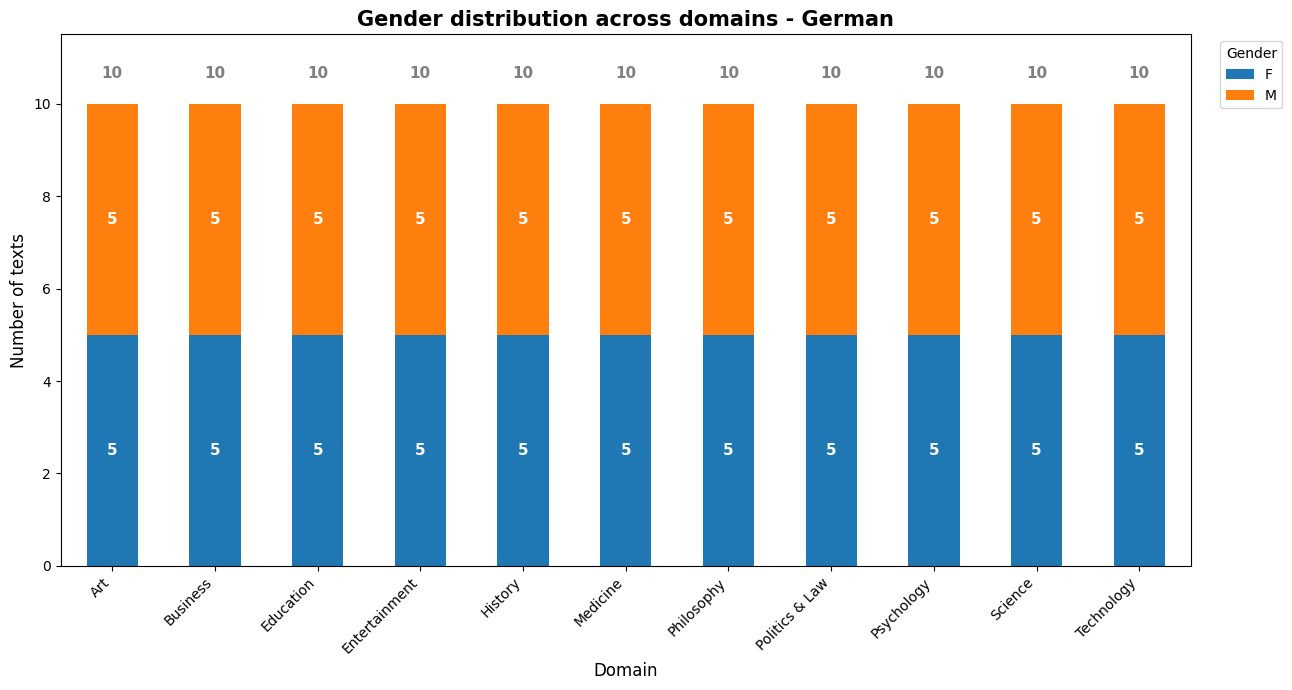

In [22]:
# German
plot_gender_stacked(
    de_texts,
    "Gender distribution across domains - German"
)

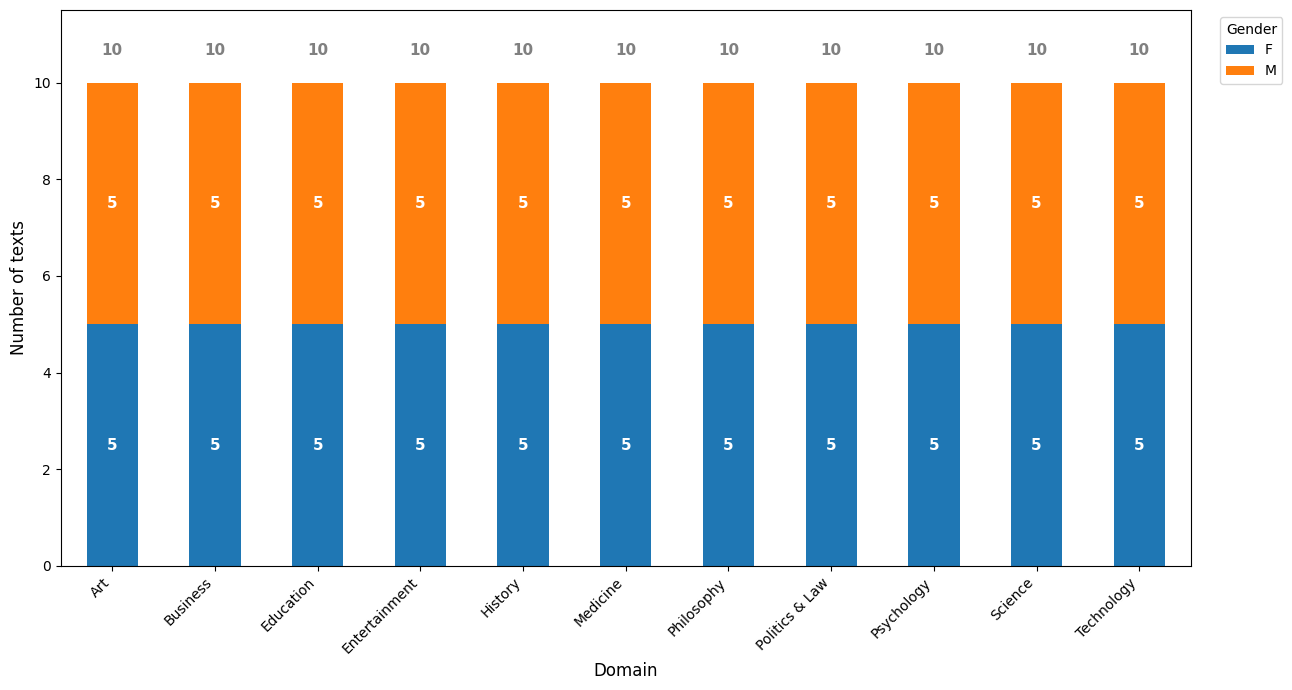

In [23]:
# German
plot_gender_stacked(
    de_texts,
    ""
)

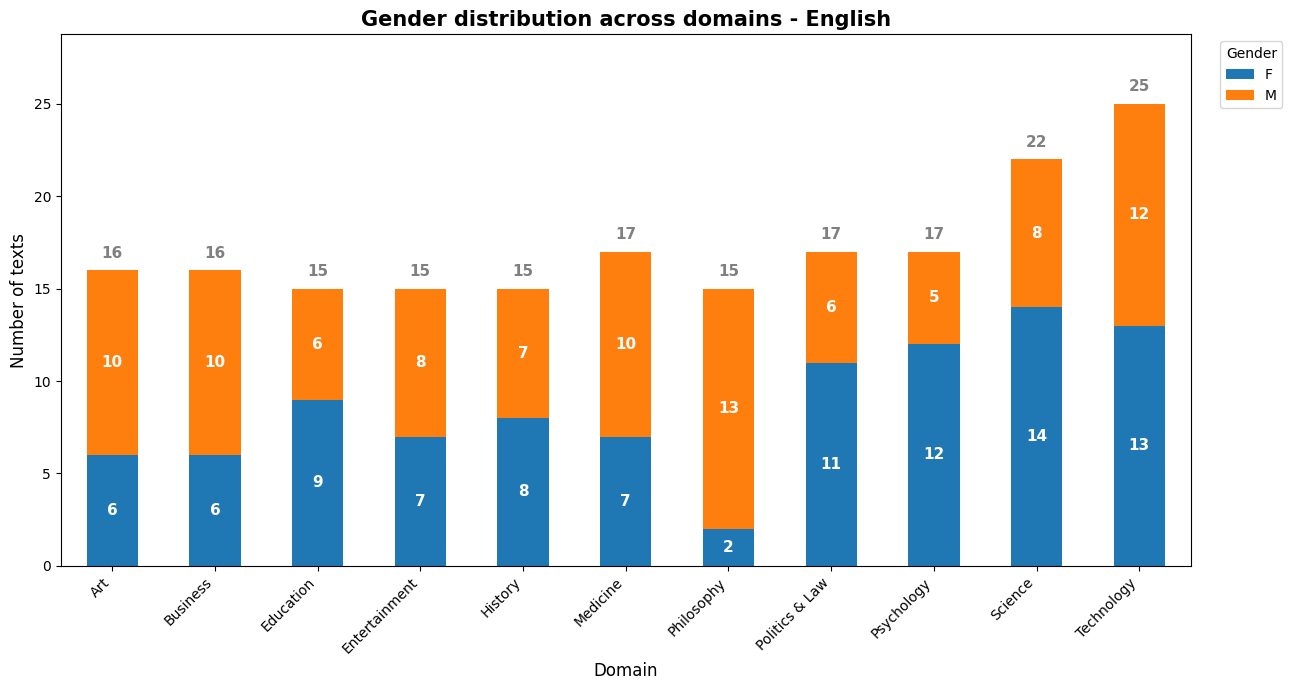

In [24]:
# English
plot_gender_stacked(
    en_texts,
    "Gender distribution across domains - English"
)

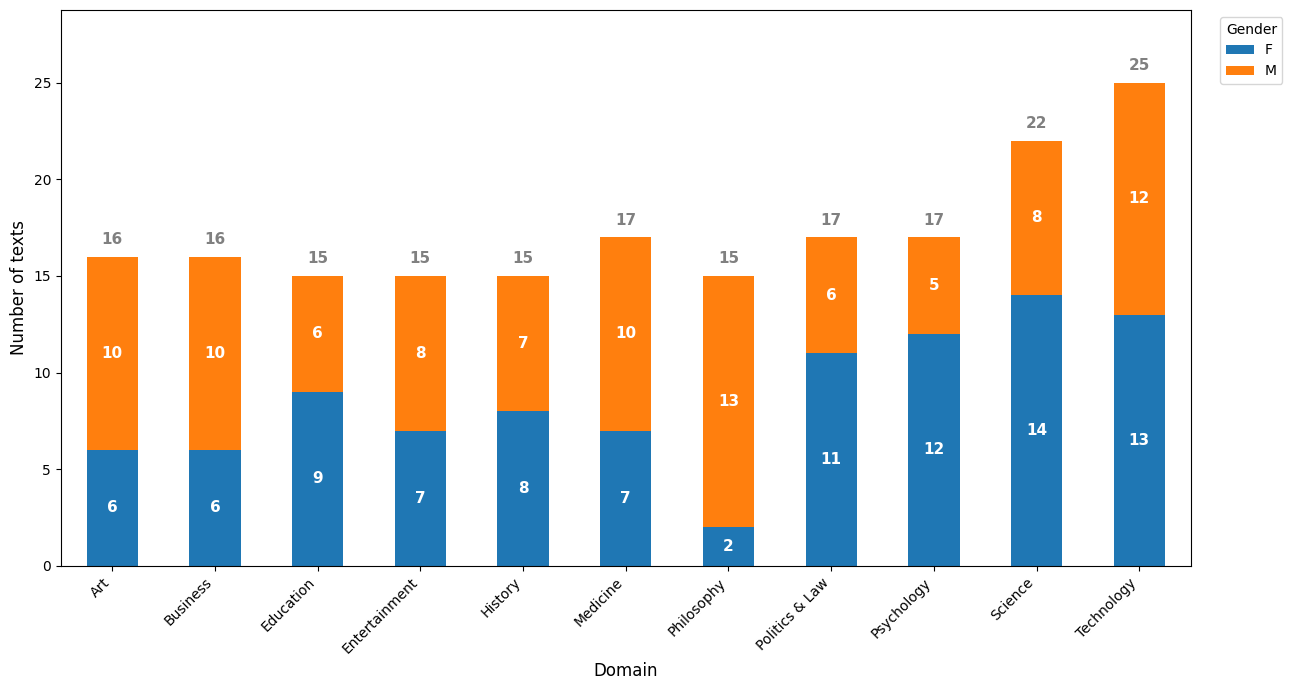

In [25]:
# English
plot_gender_stacked(
    en_texts,
    ""
)